In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from data_loader import get_dataloaders
from model import CompoundFaultNet

In [2]:
# 导入你自己编写的模块
def calculate_accuracy(outputs, labels):
    """
    计算多标签分类的准确率。
    输出概率 > 0.5 视为预测存在该故障 (1)，否则为不存在 (0)。
    核心逻辑：只有当一个样本的 3 个标签全预测对时，才算真正解耦成功。
    """
    preds = (outputs > 0.5).float()
    # 比较每一行的预测和真实标签是否完全相等
    correct = (preds == labels).all(dim=1).float().sum()
    return correct / labels.size(0)

In [3]:
# 1. 硬件设备检测
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 当前使用的计算设备: {device}")
# 2. 准备数据管道
# 注意：这里的 base_dir 请替换为你实际的 BJTU 数据集相对或绝对路径
BASE_DIR = '../../数据集/BJTU/'
print("\n📦 正在加载并预处理数据，这可能需要一些时间...")
loader_src_train, loader_src_test, loader_joint_tune, loader_tgt_test = get_dataloaders(
    base_dir=BASE_DIR, 
    fs=64000, 
    sample_length=8192, 
    num_samples=100, 
    batch_size=20, 
    tune_size=20 # 仅用 20 个复合故障样本进行微调，模拟小样本场景
)

🖥️ 当前使用的计算设备: cuda

📦 正在加载并预处理数据，这可能需要一些时间...
🚀 开始加载原始数据并切分样本...
⏳ 正在进行连续小波变换 (CWT) 及图像预处理，请稍候...
🧮 正在构建特征张量与多标签...
✅ DataLoader 封装完成！


In [8]:
# 3. 初始化模型、损失函数和优化器
# num_classes=3 对应 BJTU 的 3 个基础故障部位 [内圈, 外圈, 滚动体]
model = CompoundFaultNet(num_classes=3).to(device)

# 论文明确采用多标签分类，所以使用二元交叉熵损失 (Binary Cross-entropy) [cite: 272, 290, 291]
criterion = nn.BCELoss() 

# 论文设定 Adam 优化器，初始学习率为 0.001 [cite: 622]
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 100 # 论文中设定的迭代次数 [cite: 648]

# =========================================================
# 阶段一：源域预训练 (Phase 1: Source Domain Pre-training)
# =========================================================
print("\n" + "="*50)
print("🚀 阶段一：开始源域单故障数据预训练...")
print("="*50)

start_time = time.time()
for epoch in range(epochs):
    model.train()
    total_loss, total_acc = 0.0, 0.0
    
    for batch_X, batch_y in loader_src_train:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_acc += calculate_accuracy(outputs, batch_y).item()
        
    avg_loss = total_loss / len(loader_src_train)
    avg_acc = total_acc / len(loader_src_train)
    
    # 每 10 轮打印一次进度
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Accuracy: {avg_acc*100:.2f}%")

print(f"✅ 阶段一预训练完成！耗时: {time.time() - start_time:.2f} 秒")

# =========================================================
# 阶段二：目标域微调 (Phase 2: Target Domain Fine-tuning)
# =========================================================
print("\n" + "="*50)
# Cell 5: 阶段二微调与阶段三测试

print("🔒 阶段二：冻结 CNN 参数，开始目标域联合微调 (克服灾难性遗忘)...")
for param in model.cnn_extractor.parameters():
    param.requires_grad = False
    
optimizer_tune = optim.Adam(model.transformer_classifier.parameters(), lr=0.0005) 

start_time = time.time()
for epoch in range(epochs):
    model.train()
    total_loss, total_acc = 0.0, 0.0
    
    # 🌟 修改点：这里改为遍历 loader_joint_tune
    for batch_X, batch_y in loader_joint_tune:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer_tune.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer_tune.step()
        
        total_loss += loss.item()
        total_acc += calculate_accuracy(outputs, batch_y).item()
        
    avg_acc = total_acc / len(loader_joint_tune)
    if (epoch + 1) % 10 == 0:
        print(f"Fine-tune Epoch [{epoch+1}/{epochs}] | Loss: {total_loss/len(loader_joint_tune):.4f} | Accuracy: {avg_acc*100:.2f}%")
print(f"✅ 阶段二完成！耗时: {time.time() - start_time:.2f} 秒")

# ...(下面阶段三的代码保持完全不变)...

# =========================================================
# 阶段三：模型验证 (Phase 3: Testing on Unseen Compound Faults)
# =========================================================
print("\n" + "="*50)
print("🎯 阶段三：在未见过的复合故障测试集上进行最终验证...")
print("="*50)

model.eval()
test_acc = 0.0
with torch.no_grad():
    for batch_X, batch_y in loader_tgt_test:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = model(batch_X)
        test_acc += calculate_accuracy(outputs, batch_y).item()
        
final_accuracy = test_acc / len(loader_tgt_test)
print(f"\n🏆 最终复合故障解耦诊断准确率: {final_accuracy*100:.2f}%\n")
# ... 前面的代码 (阶段三测试结束) ...
final_accuracy = test_acc / len(loader_tgt_test)
print(f"\n🏆 最终复合故障解耦诊断准确率: {final_accuracy*100:.2f}%\n")

# =========================================================
# 🌟 新增：保存模型权重 🌟
# =========================================================
save_path = "cnn_transformer_best.pth"
torch.save(model.state_dict(), save_path)
print(f"💾 模型权重已成功保存至: {save_path}")
 



🚀 阶段一：开始源域单故障数据预训练...
Epoch [10/100] | Loss: 0.3080 | Accuracy: 57.50%
Epoch [20/100] | Loss: 0.1343 | Accuracy: 89.38%
Epoch [30/100] | Loss: 0.1255 | Accuracy: 89.69%
Epoch [40/100] | Loss: 0.0974 | Accuracy: 92.81%
Epoch [50/100] | Loss: 0.0356 | Accuracy: 98.12%
Epoch [60/100] | Loss: 0.0476 | Accuracy: 97.19%
Epoch [70/100] | Loss: 0.0052 | Accuracy: 100.00%
Epoch [80/100] | Loss: 0.0035 | Accuracy: 100.00%
Epoch [90/100] | Loss: 0.0026 | Accuracy: 100.00%
Epoch [100/100] | Loss: 0.0020 | Accuracy: 100.00%
✅ 阶段一预训练完成！耗时: 45.81 秒

🔒 阶段二：冻结 CNN 参数，开始目标域联合微调 (克服灾难性遗忘)...
Fine-tune Epoch [10/100] | Loss: 0.2785 | Accuracy: 62.50%
Fine-tune Epoch [20/100] | Loss: 0.1508 | Accuracy: 75.00%
Fine-tune Epoch [30/100] | Loss: 0.1183 | Accuracy: 87.50%
Fine-tune Epoch [40/100] | Loss: 0.0884 | Accuracy: 90.00%
Fine-tune Epoch [50/100] | Loss: 0.0737 | Accuracy: 90.00%
Fine-tune Epoch [60/100] | Loss: 0.0784 | Accuracy: 85.00%
Fine-tune Epoch [70/100] | Loss: 0.0559 | Accuracy: 95.00%
Fine-t

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
from pylab import mpl

# 设置中文字体，防止图片中的中文显示为方块
mpl.rcParams["font.sans-serif"] = ["SimHei"]
mpl.rcParams["axes.unicode_minus"] = False

In [9]:
# =========================================================
# 辅助函数：将多标签向量 [1, 0, 0] 映射为具体的类别名称和索引
# =========================================================
CLASS_NAMES = ['正常', '内圈 (I)', '外圈 (O)', '滚动体 (R)', '内+外复合 (I+O)', '外+滚复合 (O+R)', '未定义/误判']

def vec2label(vec):
    """将 3D 的多标签预测/真实向量映射为具体的分类索引"""
    if np.array_equal(vec, [0, 0, 0]): return 0
    if np.array_equal(vec, [1, 0, 0]): return 1
    if np.array_equal(vec, [0, 1, 0]): return 2
    if np.array_equal(vec, [0, 0, 1]): return 3
    if np.array_equal(vec, [1, 1, 0]): return 4
    if np.array_equal(vec, [0, 1, 1]): return 5
    return 6 # 如果模型输出了奇怪的组合（如 [1, 1, 1]），归为未定义

# =========================================================
# 核心函数 1：绘制多标签混淆矩阵
# =========================================================
def plot_confusion_matrix(model, loader_src_test, loader_tgt_test, device):
    print("📊 正在收集数据以生成混淆矩阵...")
    model.eval()
    
    y_true_list = []
    y_pred_list = []
    
    # 我们把源域测试集（单故障）和目标域测试集（复合故障）拼在一起画全局混淆矩阵
    loaders = [loader_src_test, loader_tgt_test]
    
    with torch.no_grad():
        for loader in loaders:
            for batch_X, batch_y in loader:
                batch_X = batch_X.to(device)
                outputs = model(batch_X)
                
                # 概率 > 0.5 视为发生该故障
                preds = (outputs > 0.5).int().cpu().numpy()
                trues = batch_y.int().cpu().numpy()
                
                # 遍历 Batch 中的每一个样本，转换为类别索引
                for i in range(preds.shape[0]):
                    y_true_list.append(vec2label(trues[i]))
                    y_pred_list.append(vec2label(preds[i]))
                    
    # 计算混淆矩阵 (排除未定义的第 6 类以保证矩阵美观，除非真的有大量误判)
    labels_idx = [0, 1, 2, 3, 4, 5]
    cm = confusion_matrix(y_true_list, y_pred_list, labels=labels_idx)
    
    # 转换为百分比
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES[:6], yticklabels=CLASS_NAMES[:6],
                annot_kws={"size": 12})
    
    plt.title('CNN-Transformer 复合故障解耦混淆矩阵', fontsize=16)
    plt.ylabel('真实标签 (True Label)', fontsize=14)
    plt.xlabel('预测标签 (Predicted Label)', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('Confusion_Matrix.png', dpi=300)
    print("✅ 混淆矩阵已保存为 'Confusion_Matrix.png'")
    plt.show()

# =========================================================
# 核心函数 2：提取深层特征并绘制 t-SNE 降维聚类图
# =========================================================
def plot_tsne(model, loader_src_test, loader_tgt_test, device):
    print("🌌 正在提取全局深层特征并进行 t-SNE 降维计算 (可能需要几十秒)...")
    model.eval()
    
    features_list = []
    labels_list = []
    
    loaders = [loader_src_test, loader_tgt_test]
    
    with torch.no_grad():
        for loader in loaders:
            for batch_X, batch_y in loader:
                batch_X = batch_X.to(device)
                
                # ------ 提取 Transformer 倒数第二层 (Class Token) 的高维特征 ------
                # 1. 经过 CNN 提取局部特征
                cnn_features = model.cnn_extractor(batch_X)
                # 2. 手动复现 Transformer 的前向传播以截取 cls_out
                tc = model.transformer_classifier
                batch_size, channels, h, w = cnn_features.shape
                x = cnn_features.view(batch_size, channels, h * w).transpose(1, 2)
                x = tc.projection(x)
                cls_tokens = tc.cls_token.expand(batch_size, -1, -1)
                x = torch.cat((cls_tokens, x), dim=1)
                x = x + tc.pos_embedding
                x = tc.transformer(x)
                
                # 这就是具有全局感受野和故障解耦能力的 24 维深层特征
                cls_out = x[:, 0, :] 
                # -----------------------------------------------------------------
                
                features_list.append(cls_out.cpu().numpy())
                
                # 转换标签
                trues = batch_y.int().cpu().numpy()
                for i in range(trues.shape[0]):
                    labels_list.append(vec2label(trues[i]))
                    
    features_concat = np.vstack(features_list)
    labels_concat = np.array(labels_list)
    
    # 过滤掉标签为 6 (未定义) 的噪声点
    valid_idx = labels_concat < 6
    features_concat = features_concat[valid_idx]
    labels_concat = labels_concat[valid_idx]
    
    # 执行 t-SNE 降维 (从 24 维降到 2 维)
    tsne = TSNE(n_components=2, init='pca', random_state=42, perplexity=30)
    features_2d = tsne.fit_transform(features_concat)
    
    # 绘图
    plt.figure(figsize=(10, 8))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    markers = ['o', 's', '^', 'D', 'v', 'p']
    
    for i in range(6):
        idx = labels_concat == i
        plt.scatter(features_2d[idx, 0], features_2d[idx, 1], 
                    c=colors[i], marker=markers[i], label=CLASS_NAMES[i], 
                    alpha=0.8, edgecolors='w', s=80)
        
    plt.title('t-SNE 高维故障特征聚类可视化', fontsize=16)
    plt.xlabel('Dimension 1', fontsize=14)
    plt.ylabel('Dimension 2', fontsize=14)
    plt.legend(title="故障类别", loc="best", fontsize=11, title_fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig('tSNE_Visualization.png', dpi=300)
    print("✅ t-SNE 聚类图已保存为 'tSNE_Visualization.png'")
    plt.show()



🖥️ 当前使用的计算设备: cuda
🚀 开始加载原始数据并切分样本...
⏳ 正在进行连续小波变换 (CWT) 及图像预处理，请稍候...
🧮 正在构建特征张量与多标签...
✅ DataLoader 封装完成！
📂 成功加载预训练模型: cnn_transformer_best.pth
📊 正在收集数据以生成混淆矩阵...
✅ 混淆矩阵已保存为 'Confusion_Matrix.png'


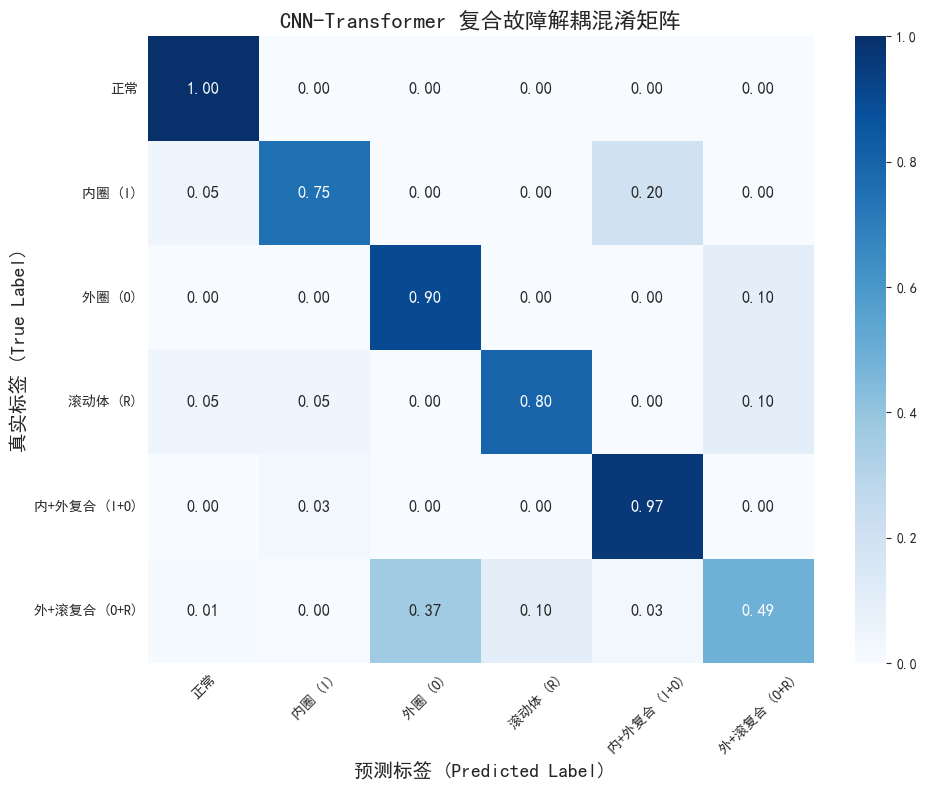

🌌 正在提取全局深层特征并进行 t-SNE 降维计算 (可能需要几十秒)...
✅ t-SNE 聚类图已保存为 'tSNE_Visualization.png'


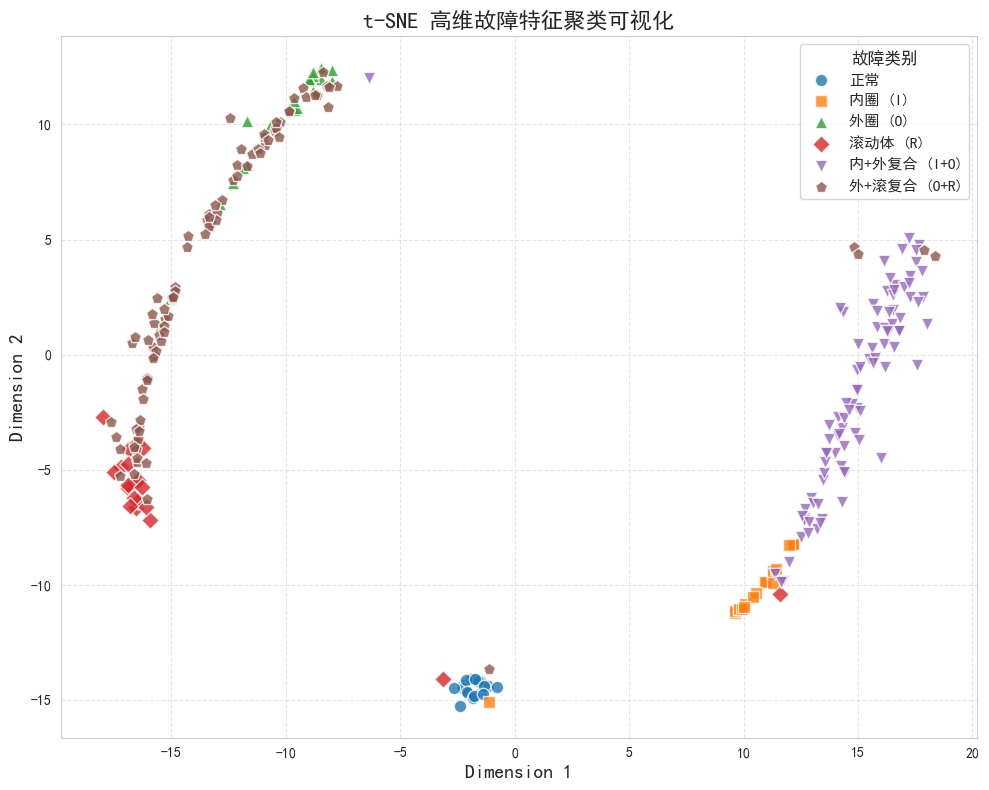

In [10]:
# =========================================================
# 如何调用这两个函数
# =========================================================
if __name__ == "__main__":
    from data_loader import get_dataloaders
    from model import CompoundFaultNet
    import torch
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🖥️ 当前使用的计算设备: {device}")
    
    # 1. 重新获取数据加载器 (直接复用你之前的参数)
    BASE_DIR = '../../数据集/BJTU/'
    loader_src_train, loader_src_test, loader_tgt_tune, loader_tgt_test = get_dataloaders(
        base_dir=BASE_DIR, fs=64000, sample_length=8192, num_samples=100, batch_size=20, tune_size=20
    )
    
    # 2. 实例化一个结构为空的模型
    trained_model = CompoundFaultNet(num_classes=3).to(device)
    
    # 3. 🌟 加载你刚才保存的权重 🌟
    model_path = "cnn_transformer_best.pth"
    trained_model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"📂 成功加载预训练模型: {model_path}")
    
    # 4. 调用画图函数
    plot_confusion_matrix(trained_model, loader_src_test, loader_tgt_test, device)
    plot_tsne(trained_model, loader_src_test, loader_tgt_test, device)